(dimensionality_reduction_and_clustering)=

# Choosing dimensionality reductions

Single-cell RNA data describe each cell with thousands of gene measurements. We cannot
view all those dimensions at once, and noisy features can obscure useful similarities.
Principal component analysis (PCA) compresses the selected features into a smaller set
of coordinates that CyteArc uses to find neighbours and build a graph.

UMAP, densMAP, and t-SNE turn that neighbourhood graph into a two-dimensional view.
Their settings change how the graph looks without changing its edges. These layouts
are visual summaries, not alternative cluster assignments. Choosing how many PCA
dimensions to retain does change the graph: too few can merge distinct populations,
while too many can bring technical variation and noise back into the comparison.

Here we compare PCA dimension counts, UMAP packing, and all three layout methods on a
prepared PBMC analysis. We will judge the views by whether known populations and local
relationships remain visible, rather than by how tidy the pictures look.

(clustering)=

See [](clustering.ipynb) for choosing and interpreting cluster assignments.

## Open the prepared analysis

In [1]:
# Load tools for comparing partitions and displaying their layouts.
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cytearc

# Keep routine progress messages out of the teaching output.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="cytearc_datasets", zarr=True
)

Started: 2026-10-08T11:03:07.783962Z | Wall time: 6.259 s

Open the downloaded store and its saved analysis.

In [2]:
# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Open the prepared baseline for the comparisons below.
baseline = ds.pipeline.open(label="docs_default")

# Keep the normalization fixed while comparing reductions.
normalized = baseline["normalized"]

# Reuse the saved UMAP coordinates.
umap = baseline["umap"]

# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

Started: 2026-10-08T11:03:14.053720Z | Wall time: 5.587 s

The saved analysis used 15 PCs; CyteArc's current default is 21. We keep the example's cells,
genes, and normalization fixed so we can explore what changing the number of PCs does.

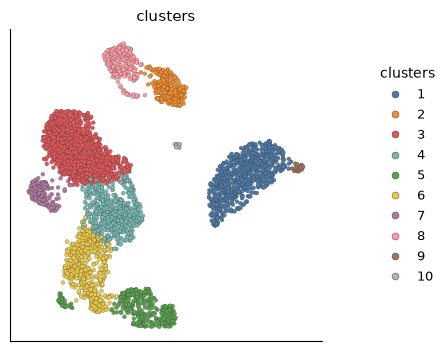

Started: 2026-10-08T11:03:19.644668Z | Wall time: 0.872 s

In [3]:
# Inspect the baseline clusters before changing PCA dimensions.
ds.plots.embedding(run=baseline, color_by="clusters")

## Compare PCA dimension counts

Build each candidate from the same normalized data and cluster each graph by passing it explicitly.
Retain the 15-component graph and initialization for the layout comparisons below.
The 15-component graph and clusters come from the saved analysis. The 10- and 30-component
graphs are built below.

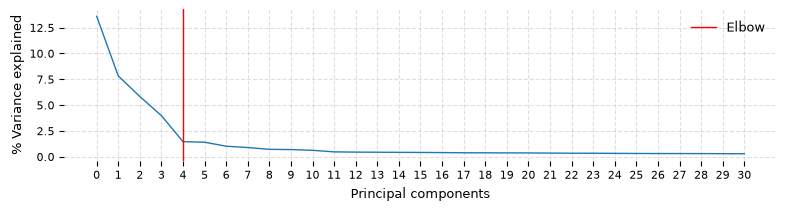

Started: 2026-10-08T11:03:20.519748Z | Wall time: 38.635 s

In [4]:
# Compare three PCA dimension counts.
dimension_counts = (10, 15, 30)

# Reuse the baseline graph built from 15 PCs.
graph_15 = baseline["connectivity_map"]

# Reuse the baseline clustering for the 15-PC comparison.
cluster_refs = {15: baseline["leiden_0.5"]}

# Rebuild only the alternatives to the saved 15-PC analysis.
for dimensions in (10, 30):

    # Fit PCA with the current dimension count.
    pca = ds.reduction.pca(
        normalized, dims=dimensions, show_elbow_plot=dimensions == 30
    )

    # Build an index over these PCA coordinates.
    ann = ds.graph.ann_index(pca)

    # Query the same number of neighbors for every candidate.
    neighbors = ds.graph.neighbors(ann, k=11)

    # Build connectivity from this candidate's neighbors.
    graph = ds.graph.connectivity(neighbors)

    # Cluster this candidate graph at the fixed resolution.
    cluster_refs[dimensions] = ds.clusters.leiden(graph, resolution=0.5)

# Reuse the same initialization for the layout comparisons.
initialization_15 = baseline["embedding_initialization"]

# Load each candidate's labels in the common cell order.
cluster_values = {
    dimensions: np.asarray(
        ds.artifacts.load(cluster_refs[dimensions])["values"][:]
    )
    for dimensions in dimension_counts
}

PCA axes represent decreasing amounts of variation in the selected genes.
An early bend in the elbow plot means later axes each add less variance. It suggests a range to
investigate, rather than a single correct cutoff. CyteArc fits one extra component for this plot;
when reusing a saved PCA result, it may warn that the plot is unavailable.
Too few axes can merge distinct populations; too many can restore technical variation and noise.
Compare graph connectivity, cluster stability, and marker coherence when the choice is uncertain.

Compare cluster sizes as well as the number of clusters. Cluster numbers can change between
analyses, so matching row numbers do not necessarily identify the same cells.

In [5]:
# Count cells per cluster for each PCA dimension count.
cluster_sizes = pd.DataFrame(
    {
        dimensions: pd.Series(cluster_values[dimensions]).value_counts()
        for dimensions in dimension_counts
    }
).fillna(0).astype(int)

# Label both comparison axes before displaying the cluster sizes.
cluster_sizes.rename_axis(index="cluster", columns="PCs")

PCs,10,15,30
cluster,,,
1,602,716,704
2,127,239,237
3,248,1237,1299
4,738,506,601
5,537,318,319
6,298,487,317
7,363,149,144
8,149,256,258
9,245,25,17


Started: 2026-10-08T11:03:59.159931Z | Wall time: 0.036 s

In [6]:
# Compare partition agreement between PCA dimension counts.
pd.Series(
    {
        f"{first} vs {second} PCs": ds.clusters.compute_concordance(
            cluster_refs[first], cluster_refs[second]
        )
        for first, second in combinations(dimension_counts, 2)
    },
    name="adjusted Rand index",
)

10 vs 15 PCs    0.679137
10 vs 30 PCs    0.670148
15 vs 30 PCs    0.838912
Name: adjusted Rand index, dtype: float64

Started: 2026-10-08T11:03:59.199614Z | Wall time: 0.157 s

The adjusted Rand index measures partition agreement without requiring matching cluster numbers.
It does not identify the biologically correct dimension count. Inspect markers and QC metrics
where the partitions disagree. See [](clustering.ipynb) for more on cluster evidence.

## Compare UMAP packing

The layout below uses the explicit 15-component graph.
Colouring by each Leiden partition shows how the 10-, 15-, and 30-component cuts land on the same coordinates.

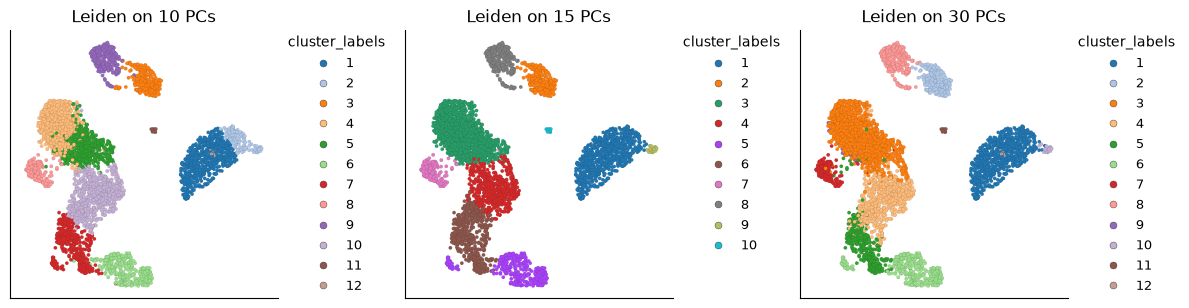

Started: 2026-10-08T11:03:59.360421Z | Wall time: 2.189 s

In [7]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 3, figsize=(12, 4))

# Draw each comparison on its own labeled axis.
for axis, dimensions in zip(axes, dimension_counts, strict=True):

    # Place each candidate clustering on the common baseline UMAP.
    ds.plots.embedding(
        layout=umap,
        color_by=cluster_refs[dimensions],
        target=axis,
        show_titles=False,
        show=False,
    )

    # Label the panel with the quantity being compared.
    axis.set_title(f"Leiden on {dimensions} PCs")

# Adjust spacing so panel labels remain readable.
figure.tight_layout()

# Display the completed figure.
figure

`min_dist` controls how tightly local groups can pack, while `spread` controls the overall scale.
These parameters change appearance without changing the input graph.
A second UMAP with a smaller `min_dist` shows packing on the same neighbours.

In [8]:
# Change UMAP packing while holding the graph and initialization fixed.
umap_tight = ds.embeddings.umap(graph_15, initialization_15, min_dist=0.1)

Started: 2026-10-08T11:04:01.554810Z | Wall time: 4.318 s

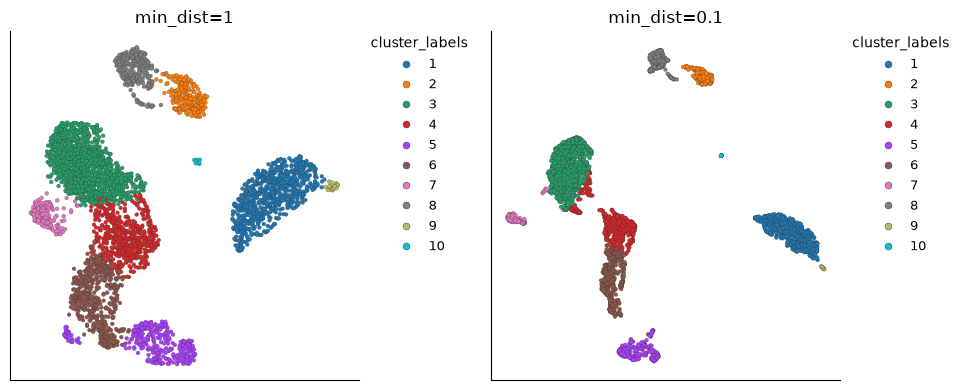

Started: 2026-10-08T11:04:05.876661Z | Wall time: 1.272 s

In [9]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 2, figsize=(10, 4))

# Draw each comparison on its own labeled axis.
for axis, layout, title in zip(
    axes, (umap, umap_tight), ("min_dist=1", "min_dist=0.1"), strict=True
):

    # Compare UMAP packing with the same cluster colors.
    ds.plots.embedding(
        layout=layout,
        color_by=cluster_refs[15],
        target=axis,
        show_titles=False,
        show=False,
    )

    # Label the panel with the quantity being compared.
    axis.set_title(title)

# Adjust spacing so panel labels remain readable.
figure.tight_layout()

# Display the completed figure.
figure

## Optional: compare densMAP and t-SNE

In [10]:
# Fit densMAP to the same graph and initialization.
densmap = ds.embeddings.umap(graph_15, initialization_15, use_density_map=True)

Started: 2026-10-08T11:04:07.153430Z | Wall time: 6.771 s

densMAP adds a density-preservation objective.
Relative packing can differ from UMAP; plot area is still not a direct estimate of cell frequency.

CyteArc's t-SNE consumes the same neighbourhood graph.
Computing a new embedding needs the optional `sgtsnepi` package from the `tsne` extra (see {ref}`Optional t-SNE <installation_tsne>`); reusing a saved embedding does not.

In [11]:
# Fit t-SNE to that graph without requesting iteration logs.
tsne = ds.embeddings.tsne(graph_15, initialization_15, verbose=False)

Started: 2026-10-08T11:04:13.930429Z | Wall time: 1.649 s

### Read the layouts cautiously

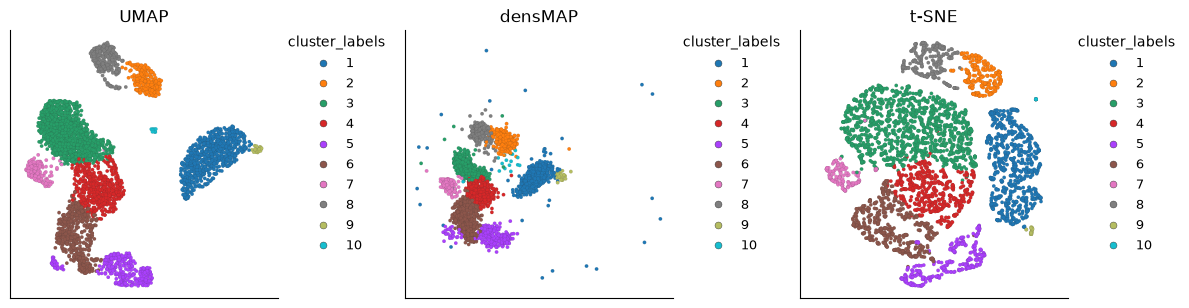

Started: 2026-10-08T11:04:15.583742Z | Wall time: 2.140 s

In [12]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 3, figsize=(12, 4))

# Pair each saved layout with its display title.
layout_comparisons = (("UMAP", umap), ("densMAP", densmap), ("t-SNE", tsne))

# Draw each comparison on its own labeled axis.
for axis, (title, layout) in zip(axes, layout_comparisons, strict=True):

    # Compare UMAP, densMAP, and t-SNE with the same cluster colors.
    ds.plots.embedding(
        layout=layout,
        color_by=cluster_refs[15],
        target=axis,
        show_titles=False,
        show=False,
    )

    # Label the panel with the quantity being compared.
    axis.set_title(title)

# Adjust spacing so panel labels remain readable.
figure.tight_layout()

# Display the completed figure.
figure

The three panels share cells, graph, and cluster labels.
A useful comparison asks whether local neighbours and known populations remain visible.
Differences in global orientation, distance, empty space, or apparent island size do not demonstrate different biology.
A layout that hides connected transitions or separates obvious technical covariates needs further investigation.

(run-paris-clustering-and-inspect-the-tree)=

## Next: clustering

Continue with [](clustering.ipynb) to compare ways of grouping cells.
That guide distinguishes graph connectivity between groups from the Paris hierarchy and covers both adaptive and fixed cuts.